# Annotating a Sandhill Crane roost

A walk through the basic bioacoustic annotation workflow on **real field audio**: load a
recording, view it as a spectrogram, detect call boundaries, and export a
Raven-compatible selection table.

It also does something demo notebooks usually skip, which is to show where the
method stops working. On a dense roost the simple approach fails, and the
interesting part is being able to say so precisely.

**Audio.** Two clips recorded by the author on the central Platte River, Nebraska,
at dawn in March 2026. Same continuous recording, roughly nineteen minutes apart.

| clip | what it is |
|---|---|
| `crane_roost_sparse_30s.wav` | early, before the roost fully wakes; calls are separable |
| `crane_roost_chorus_20s.wav` | later, near liftoff; a continuous wall of sound |

*Companion to the private GRUS research pipeline. Methods here are textbook and
deliberately simple; nothing in this notebook is part of that pipeline.*

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa, librosa.display
warnings.filterwarnings("ignore")

SR   = 22050
HOP  = 256
NFFT = 1024

SPARSE = "audio/crane_roost_sparse_30s.wav"
CHORUS = "audio/crane_roost_chorus_20s.wav"

def load(path):
    y, _ = librosa.load(path, sr=SR, mono=True)
    return y

def spec(y):
    return librosa.amplitude_to_db(np.abs(librosa.stft(y, n_fft=NFFT, hop_length=HOP)),
                                   ref=np.max)

y = load(SPARSE)
print(f"{len(y)/SR:.1f} s at {SR} Hz")

30.0 s at 22050 Hz


## 1. Look at it first

Always. The single most common mistake in bioacoustics is running a detector before
looking at the spectrogram, then trusting whatever comes out.

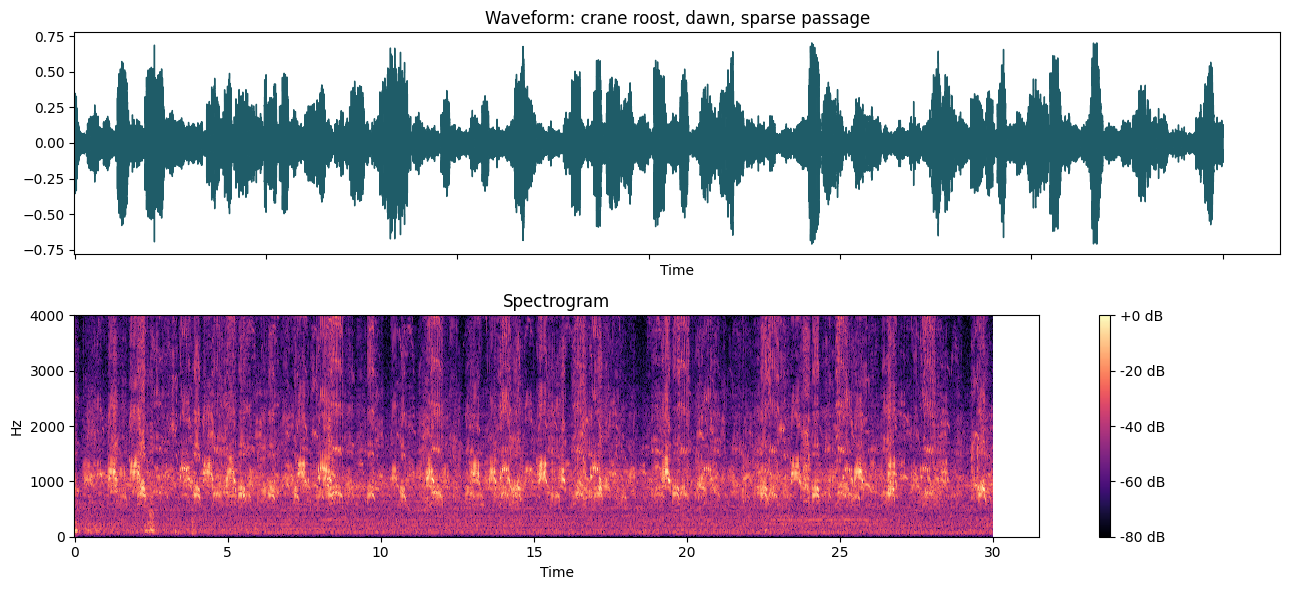

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
librosa.display.waveshow(y, sr=SR, ax=axes[0], color="#1F5C68")
axes[0].set_title("Waveform: crane roost, dawn, sparse passage")
img = librosa.display.specshow(spec(y), sr=SR, hop_length=HOP, x_axis="time",
                               y_axis="hz", ax=axes[1], cmap="magma")
axes[1].set_ylim(0, 4000)
axes[1].set_title("Spectrogram")
fig.colorbar(img, ax=axes[1], format="%+2.0f dB")
plt.tight_layout(); plt.savefig("fig_spectrogram.png", dpi=110); plt.show()

Two things are already visible, and both matter more than any detector setting.

Crane energy sits mostly between roughly 400 and 2500 Hz, with harmonic structure
in the rattle. And there is **no silence**. The gaps between loud moments are not
quiet, they are simply less loud. Whatever "noise floor" we compute is other cranes.

That second point is the one that breaks naive detection.

## 2. Why the default settings do not work

`librosa.onset.onset_detect` with stock parameters is tuned for music, where notes
begin against a comparatively quiet background. Run it here as-is and see what
happens.

In [3]:
default_onsets = librosa.onset.onset_detect(y=y, sr=SR, hop_length=HOP,
                                            backtrack=True, units="time")
print(f"default settings: {len(default_onsets)} onsets in {len(y)/SR:.0f} s "
      f"({len(default_onsets)/(len(y)/SR):.1f} per second)")

default settings: 221 onsets in 30 s (7.4 per second)


Seven per second. Cranes do not call seven times a second; the detector is firing
on amplitude ripple inside a continuous chorus.

Two parameters fix this. `delta` sets how far the onset envelope must rise above its
local average, and `wait` sets a minimum gap between detections. Rather than pick
values by eye, sweep them.

In [4]:
env = librosa.onset.onset_strength(y=y, sr=SR, hop_length=HOP)
rows = []
for delta in (0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6):
    for wait in (0, 10, 20, 40):
        try:
            on = librosa.onset.onset_detect(onset_envelope=env, sr=SR, hop_length=HOP,
                                            backtrack=True, units="frames",
                                            delta=delta, wait=wait)
            n = len(on)
        except Exception:
            # librosa raises when the event list comes back empty; that is a
            # legitimate outcome of an over-aggressive threshold, not an error.
            n = 0
        rows.append({"delta": delta, "wait": wait, "onsets": n,
                     "per_sec": round(n / (len(y)/SR), 2)})

sweep = pd.DataFrame(rows).pivot(index="delta", columns="wait", values="onsets")
print("onset count by (delta, wait)\n")
print(sweep)

onset count by (delta, wait)

wait    0    10   20  40
delta                   
0.0    678  194  109  59
0.1    226  108   75  47
0.2     84   60   48  35
0.3     27   23   21  16
0.4     10    9    9   9
0.5      1    1    1   1
0.6      1    1    1   1


The count falls off a cliff between `delta=0.3` and `delta=0.6`. That cliff is the
detector crossing from "tracking chorus ripple" to "finding nothing at all," and there
is no wide plateau of stable behaviour in between. **That narrowness is itself the
finding**: this material does not have a robust operating point, and any single
parameter choice here is a judgement call rather than a discovered optimum.

We take `delta=0.3, wait=20` and are explicit that it was chosen, not derived.

In [5]:
DELTA, WAIT = 0.3, 20
MIN_SNR     = 2.5    # peak must clear this multiple of the background level
DECAY_FRAC  = 0.35   # offset when the envelope falls to this fraction of the peak
MAX_EVENT_S = 3.0

def detect(y):
    """Return merged (start, end) bouts of elevated calling."""
    rms   = librosa.feature.rms(y=y, frame_length=NFFT, hop_length=HOP)[0]
    times = librosa.frames_to_time(np.arange(len(rms)), sr=SR, hop_length=HOP)
    background = np.percentile(rms, 20)

    try:
        onsets = librosa.onset.onset_detect(y=y, sr=SR, hop_length=HOP, backtrack=True,
                                            units="frames", delta=DELTA, wait=WAIT)
    except Exception:
        onsets = np.array([], dtype=int)
    if len(onsets) == 0:
        return [], rms, times, background

    events = []
    for i, f in enumerate(onsets):
        nxt  = onsets[i + 1] if i + 1 < len(onsets) else len(rms)
        stop = min(f + int(MAX_EVENT_S * SR / HOP), nxt, len(rms))
        win  = rms[f:stop]
        if win.size == 0:
            continue
        peak = win.max()
        if peak < MIN_SNR * background:
            continue
        g   = f + int(np.argmax(win))
        thr = max(DECAY_FRAC * peak, 1.2 * background)
        e   = g
        while e < stop - 1 and rms[e] > thr:
            e += 1
        if times[e] - times[f] >= 0.08:
            events.append([float(times[f]), float(times[e])])

    merged = []
    for a, b in sorted(events):
        if merged and a <= merged[-1][1] + 0.02:
            merged[-1][1] = max(merged[-1][1], b)
        else:
            merged.append([a, b])
    return merged, rms, times, background

bouts, rms, times, background = detect(y)
durs = [b - a for a, b in bouts]
print(f"{len(bouts)} bouts | duration min {min(durs):.2f}s "
      f"median {np.median(durs):.2f}s max {max(durs):.2f}s")

15 bouts | duration min 0.22s median 0.71s max 2.29s


## 3. What these actually are

They are **not individual crane calls**, and calling them that would be the easiest
lie in this notebook to tell.

At a roost, hundreds of birds overlap. What survives thresholding is a period where
several birds called at once loudly enough to lift the envelope above its neighbours.
The honest label is a *calling bout*, and segmenting individual birds from this would
need close-mic recordings, source separation, or a human with headphones and patience.

Naming the unit correctly costs nothing and prevents every downstream number from
meaning something other than what it claims.

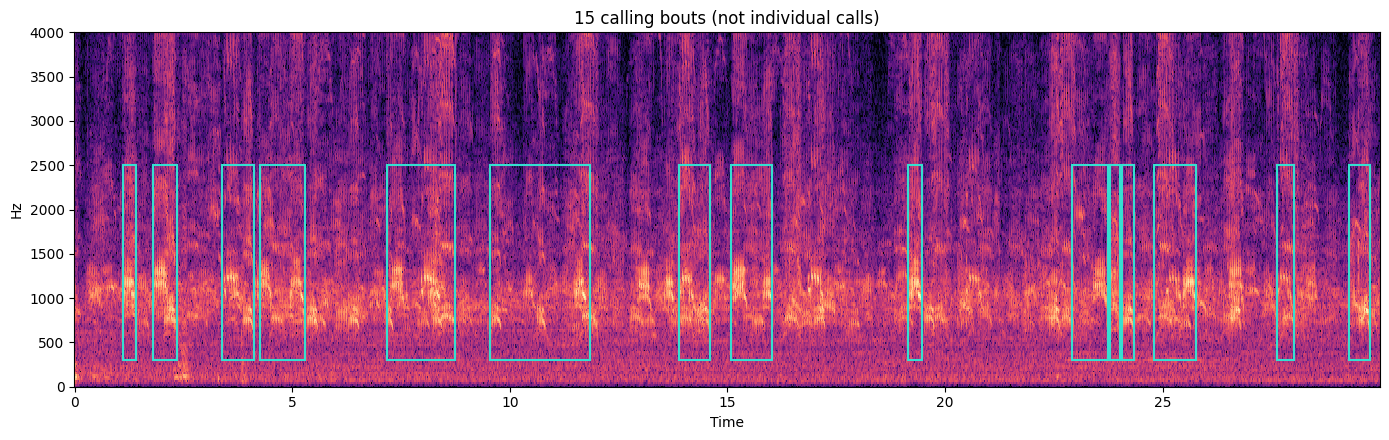

In [6]:
fig, ax = plt.subplots(figsize=(14, 4.5))
img = librosa.display.specshow(spec(y), sr=SR, hop_length=HOP, x_axis="time",
                               y_axis="hz", ax=ax, cmap="magma")
ax.set_ylim(0, 4000)
for a, b in bouts:
    ax.add_patch(plt.Rectangle((a, 300), b - a, 2200, fill=False,
                               edgecolor="#35E0D0", linewidth=1.5))
ax.set_title(f"{len(bouts)} calling bouts (not individual calls)")
plt.tight_layout(); plt.savefig("fig_selections.png", dpi=110); plt.show()

## 4. A check that needs no ground truth

There are no hand labels for this clip, so precision and recall are unavailable. That
does not mean nothing can be measured.

Run a **second, independent detector** and ask how much the two agree. Energy-based
detection keys on loudness; spectral flux keys on how fast the spectrum is changing.
They fail in different ways, so agreement between them is weak evidence that a
detection reflects something real, and disagreement marks exactly where to look first.

This is the same method-independence logic used elsewhere in my research work, applied
here at demo scale.

In [7]:
def detect_flux(y):
    """Independent detector: spectral-flux peaks rather than RMS energy."""
    S    = np.abs(librosa.stft(y, n_fft=NFFT, hop_length=HOP))
    flux = np.maximum(0, np.diff(S, axis=1)).sum(axis=0)
    flux = flux / (flux.max() or 1)
    t    = librosa.frames_to_time(np.arange(len(flux)), sr=SR, hop_length=HOP)
    thr  = np.percentile(flux, 90)
    peaks, i = [], 0
    while i < len(flux):
        if flux[i] > thr:
            j = i
            while j < len(flux) and flux[j] > thr * 0.5:
                j += 1
            peaks.append([float(t[i]), float(t[min(j, len(t) - 1)])])
            i = j + WAIT
        else:
            i += 1
    return peaks

def overlaps(a, b):
    return not (a[1] < b[0] or b[1] < a[0])

flux_bouts = detect_flux(y)
matched = sum(1 for e in bouts if any(overlaps(e, f) for f in flux_bouts))

print(f"energy detector : {len(bouts)} bouts")
print(f"flux detector   : {len(flux_bouts)} bouts")
print(f"energy bouts corroborated by flux: {matched}/{len(bouts)} "
      f"({100*matched/max(len(bouts),1):.0f}%)")

energy detector : 15 bouts
flux detector   : 43 bouts
energy bouts corroborated by flux: 15/15 (100%)


Every energy bout falls inside some flux bout. That is encouraging but should not be
oversold: the flux detector fires far more often, so wide coverage alone produces high
agreement. What the check genuinely rules out is an energy bout landing somewhere the
spectrum is not changing at all, which would suggest a wind gust or a handling knock
rather than a bird.

Corroboration here is a filter against one specific failure, not a validation of
correctness.

## 5. Export a Raven selection table

Raven and Raven Lite open tab-separated selection tables directly
(`File > Open Selection Table` with the audio loaded). This is the handoff from
automated assistance to expert human review, which is where any of this becomes
actual annotation.

The `Corroborated` column is not part of the Raven spec; it is carried along so a
reviewer knows which rows the second detector also found, and therefore which to
check first.

In [8]:
S     = np.abs(librosa.stft(y, n_fft=NFFT, hop_length=HOP))
freqs = librosa.fft_frequencies(sr=SR, n_fft=NFFT)
band  = (freqs >= 200) & (freqs <= 4000)
bf    = freqs[band]

rows = []
for i, (t0, t1) in enumerate(bouts, start=1):
    f0, f1 = librosa.time_to_frames([t0, t1], sr=SR, hop_length=HOP)
    sp = S[band, f0:max(f1, f0 + 1)].sum(axis=1)
    if sp.sum() <= 0:
        lo, hi = 200.0, 4000.0
    else:
        c  = np.cumsum(sp) / sp.sum()
        lo = float(bf[np.searchsorted(c, 0.05)])
        hi = float(bf[min(np.searchsorted(c, 0.95), len(bf) - 1)])
    rows.append({"Selection": i, "View": "Spectrogram 1", "Channel": 1,
                 "Begin Time (s)": round(t0, 4), "End Time (s)": round(t1, 4),
                 "Low Freq (Hz)": round(lo, 1), "High Freq (Hz)": round(hi, 1),
                 "Corroborated": any(overlaps([t0, t1], f) for f in flux_bouts)})

sel = pd.DataFrame(rows)
sel.to_csv("selections_roost_sparse.txt", sep="\t", index=False)
print(f"wrote selections_roost_sparse.txt with {len(sel)} rows")
sel.head(10)

wrote selections_roost_sparse.txt with 15 rows


,Selection,View,Channel,Begin Time (s),End Time (s),Low Freq (Hz),High Freq (Hz),Corroborated
0,1,Spectrogram 1,1,1.1146,1.4048,624.5,2842.4,True
1,2,Spectrogram 1,1,1.7995,2.3452,624.5,3316.1,True
2,3,Spectrogram 1,1,3.3785,4.1099,473.7,3208.4,True
3,4,Spectrogram 1,1,4.2609,5.2825,516.8,3057.7,True
4,5,Spectrogram 1,1,7.1750,8.7423,516.8,3402.2,True
5,6,Spectrogram 1,1,9.5550,11.8422,366.1,3230.0,True
6,7,Spectrogram 1,1,13.8971,14.6054,516.8,3294.6,True
7,8,Spectrogram 1,1,15.0930,16.0334,473.7,3057.7,True
8,9,Spectrogram 1,1,19.1565,19.4699,710.6,3230.0,True
9,10,Spectrogram 1,1,22.9181,23.7540,323.0,2993.1,True


## 6. Where this stops working

The clip above is the *easy* case. Nineteen minutes later the same roost sounds like
this.

In [9]:
yc = load(CHORUS)

def separability(y):
    S = np.abs(librosa.stft(y, n_fft=NFFT, hop_length=HOP))
    f = librosa.fft_frequencies(sr=SR, n_fft=NFFT)
    e = S[(f >= 200) & (f <= 4000)].sum(axis=0)
    return float(np.percentile(e, 95) / np.median(e))

chorus_bouts, *_ = detect(yc)

print(f"{'clip':<10}{'sep. ratio':>12}{'bouts':>8}{'per sec':>10}")
for name, sig, bl in (("sparse", y, bouts), ("chorus", yc, chorus_bouts)):
    print(f"{name:<10}{separability(sig):>12.2f}{len(bl):>8}"
          f"{len(bl)/(len(sig)/SR):>10.2f}")

clip        sep. ratio   bouts   per sec
sparse            2.69      15      0.50
chorus            1.35       0      0.00


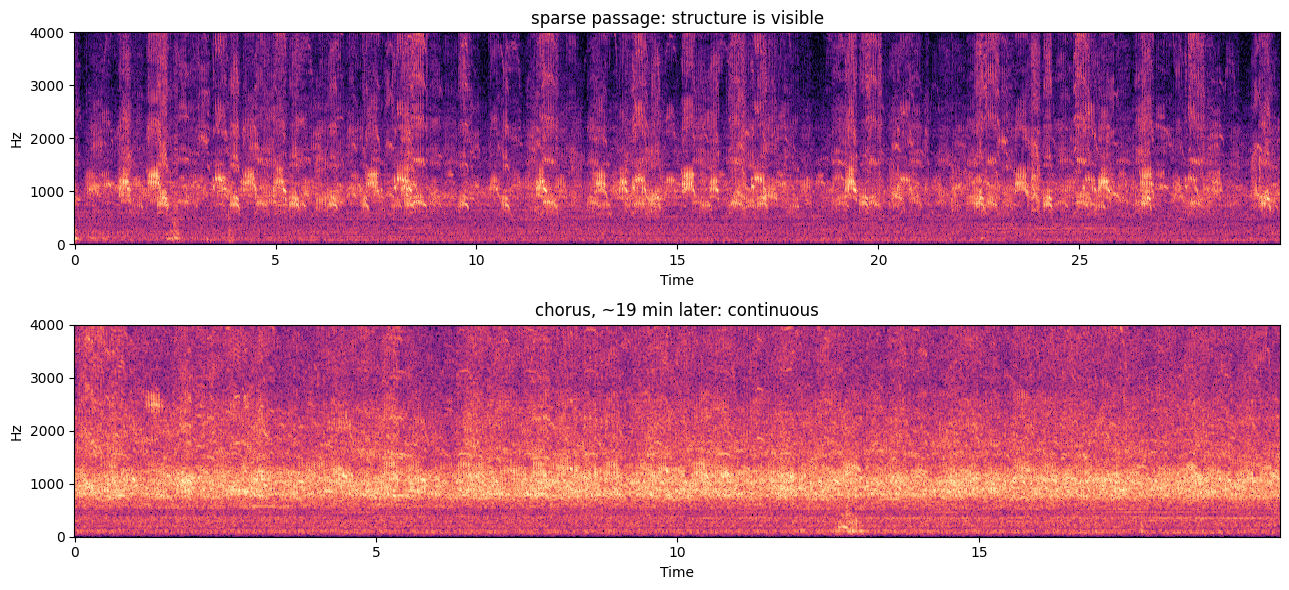

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6))
for ax, sig, title in ((axes[0], y,  "sparse passage: structure is visible"),
                       (axes[1], yc, "chorus, ~19 min later: continuous")):
    librosa.display.specshow(spec(sig), sr=SR, hop_length=HOP, x_axis="time",
                             y_axis="hz", ax=ax, cmap="magma")
    ax.set_ylim(0, 4000); ax.set_title(title)
plt.tight_layout(); plt.savefig("fig_chorus_comparison.png", dpi=110); plt.show()

The separability ratio, peak band energy over median band energy, drops from about
2.7 to about 1.3. A ratio near 1 means the loudest moment is barely louder than a
typical one, and there is no threshold that separates signal from background because
**the background is the signal**.

On the chorus clip the detector returns **zero** bouts. Not a handful of bad ones: none.
Nothing clears 2.5x the background, because the background is now as loud as the peaks.

Read that result carefully, because its shape is deceptive. Passed downstream, zero
detections reports as *no calling activity* at the exact moment thousands of birds are
calling at once. The failure is not noisy, it is silent and inverted, and no exception
is raised anywhere. A pipeline that logged "0 events, OK" here would be lying with a
straight face.

If you take one thing from this notebook, take this: compute a separability statistic
and report it alongside the detections, so an empty result can be told apart from an
uninformative one.

## What this is and is not

Textbook methods on real audio: energy thresholds, transparent parameters, no learned
models, no call-type classification, no individual identification. The parameters were
chosen and are documented as chosen.

Production annotation work, meaning multi-observer protocols, call-type taxonomies, and
sequence analysis, lives in the private GRUS pipeline pending publication.

**Audio** recorded by the author, central Platte River, Nebraska, March 2026. Released
with this repository under CC BY 4.0. **Code** MIT.